# 第3章 基本分布 (Standard Distributions)
## 3.5 非母数的方法 (Nonparametric Methods)

本ノートブックでは、特定の確率分布族（ガウス分布など）を仮定せずにデータの確率密度を柔軟に推定・分類する**非母数的方法 (Nonparametric Methods)** の数学的定式化と実装を行います。

---

### 目次
1. **3.5 母数的手法と非母数的手法の対比**
   - パラメトリック手法の限界（単峰性の制約、モデルの硬直性）
   - ノンパラメトリック手法の基本概念（局所性、次元の呪い）
2. **3.5.1 ヒストグラム法 (Histograms)**
   - ビン分割と規格化確率密度の定義式 (式 3.175)
   - ビン幅 $\Delta$ による平滑化トレードオフ（過学習と過度の平滑化）
   - 教科書 **Figure 3.13** の完全再現
3. **3.5.2 カーネル密度推定 (Kernel Densities / Parzen Windows)**
   - 局所領域確率と二項分布からの密度推定式の導出 (式 3.176 - 3.180)
   - パーツェン窓（超立方体カーネル）とガウスカーネル (式 3.181 - 3.184)
   - バンド幅 $h$ の役割と最適化、シルバーマンの経験則 (Silverman's rule of thumb)
   - 教科書 **Figure 3.14** の完全再現
4. **3.5.3 最近傍法 (Nearest-neighbours)**
   - $K$ 近傍密度推定の定式化と体積 $V$ の可変性 (式 3.180)
   - $K$ の選択と特異性（$K=1$ における発散挙動）
   - 教科書 **Figure 3.15** の完全再現
   - $K$ 近傍分類器と事後確率 $p(C_k \mid \mathbf{x}) = K_k / K$ のベイズ導出 (式 3.187 - 3.190)
   - 1近傍法 ($K=1$) とボロノイ決定境界 (Voronoi Tessellation)
   - カバー・ハートの定理 (Cover-Hart Theorem) による漸近誤り率限界
   - 教科書 **Figure 3.16** の完全再現
5. **自己検証アサーション (Self-Check Validation)**


In [1]:
import os
import sys
import numpy as np
import scipy.linalg as la
from scipy import special
import matplotlib.pyplot as plt

# リポジトリルートをパスに追加
repo_root = os.path.abspath("..")
if repo_root not in sys.path:
    sys.path.append(repo_root)

from common.plot_utils import setup_style
from common.probability import (
    HistogramDensity1D,
    KernelDensity1D,
    KernelDensityND,
    KNNDensityEstimator,
    KNNClassifier,
    get_mixture_pdf_3_5,
    get_synthetic_50_points_3_5,
    plot_figure_3_13_histogram,
    plot_figure_3_14_kernel_density,
    plot_figure_3_15_knn_density,
    plot_figure_3_16_knn_classification
)

setup_style()
print("Libraries and Section 3.5 Nonparametric modules loaded successfully.")


Libraries and Section 3.5 Nonparametric modules loaded successfully.


---
## 1. 母数的手法と非母数的手法

### 1.1 母数的手法 (Parametric Approaches) の限界
本章でこれまで扱ってきたベルヌーイ分布、多項分布、ガウス分布、フォン・ミーゼス分布などは、少数の固定されたパラメータ（平均 $\boldsymbol{\mu}$ や共分散 $\boldsymbol{\Sigma}$ など）によって確率密度の形状が一意に決定される**母数的手法 (Parametric Methods)** です。
しかし、現実の複雑なデータ生成過程に対しては以下の重大な制約があります：
1. **分布の仮定が不適切な場合の予測性能低下**:
   データ生成過程が多峰性（複数の山）を持つ場合、単一のガウス分布（必然的に単峰性）では真の分布構造を捉えることができません。
2. **モデル表現力の固定化**:
   サンプル数 $N$ が数万〜数百万に増加しても、パラメータ数が増えないためモデルの表現力が頭打ちになります。

### 1.2 非母数的手法 (Nonparametric Approaches) の基本概念
これに対し、**非母数的手法 (Nonparametric Methods)** は確率密度の形状について特定の関数形を仮定せず、データの観測点そのものを用いて局所的に密度を構成します。
データ数 $N$ の増加に応じてモデルの柔軟性が自動的にスケールする利点を持つ一方、以下で詳述する**局所平滑化パラメータの選定**と**次元の呪い (Curse of Dimensionality)** が中心的な課題となります。


---
## 2. 3.5.1 ヒストグラム法 (Histograms)

### 2.1 定式化と規格化条件
1次元の連続変数 $x$ の観測範囲を幅 $\Delta_i$ の不連続なビン（区間）に分割し、各ビン $i$ に入る観測点の個数を $n_i$ とします。
全観測点数を $N$ とするとき、ビン $i$ における規格化された確率密度 $p_i$ は次式で定義されます（式 3.175）：

$$
p_i = \frac{n_i}{N \Delta_i}
$$

各ビン上で密度を一定値 $p_i$ とする区分的定数モデルであり、全領域での積分は厳密に $1$ となります：
$$
\int p(x) dx = \sum_i p_i \Delta_i = \sum_i \frac{n_i}{N} = \frac{1}{N} \sum_i n_i = 1
$$
通常はすべてのビン幅を等しい定数 $\Delta_i = \Delta$ に設定します。

---

### 2.2 平滑化パラメータ $\Delta$ のトレードオフ
- **$\Delta$ が小さすぎる場合 ($\Delta = 0.04$)**:
  各ビンに含まれるデータ数が少なくなり、推定密度は激しいスパイク状（高バリアンス／過学習）となって真の分布にはないノイズを拾います。
- **$\Delta$ が大きすぎる場合 ($\Delta = 0.25$)**:
  過度に平滑化（高バイアス／未学習）され、真の分布の二峰性構造が完全に消失してしまいます。
- **中間的な $\Delta$ ($\Delta = 0.08$)**:
  ノイズを抑えつつ、二峰性のピーク位置と形状を最もバランスよく捉えます。

### 2.3 ヒストグラム法の長所と短所
- **長所**: 一度ヒストグラムを計算してしまえば元のデータセットを破棄できるためメモリ効率が高く、データが逐次的に到着するストリーミング環境にも容易に適応できます。
- **短所**:
  1. ビンの境界において人工的な不連続が生じる。
  2. **次元の呪い**: $D$ 次元空間の各軸を $M$ 個のビンに分割すると、総ビン数は $M^D$ となり次元に対して指数関数的に爆発します。


Figure 3.13 saved successfully to: result/fig3_13_histogram_density_estimation.png
Figure 3.13 saved successfully to: ../result/fig3_13_histogram_density_estimation.png


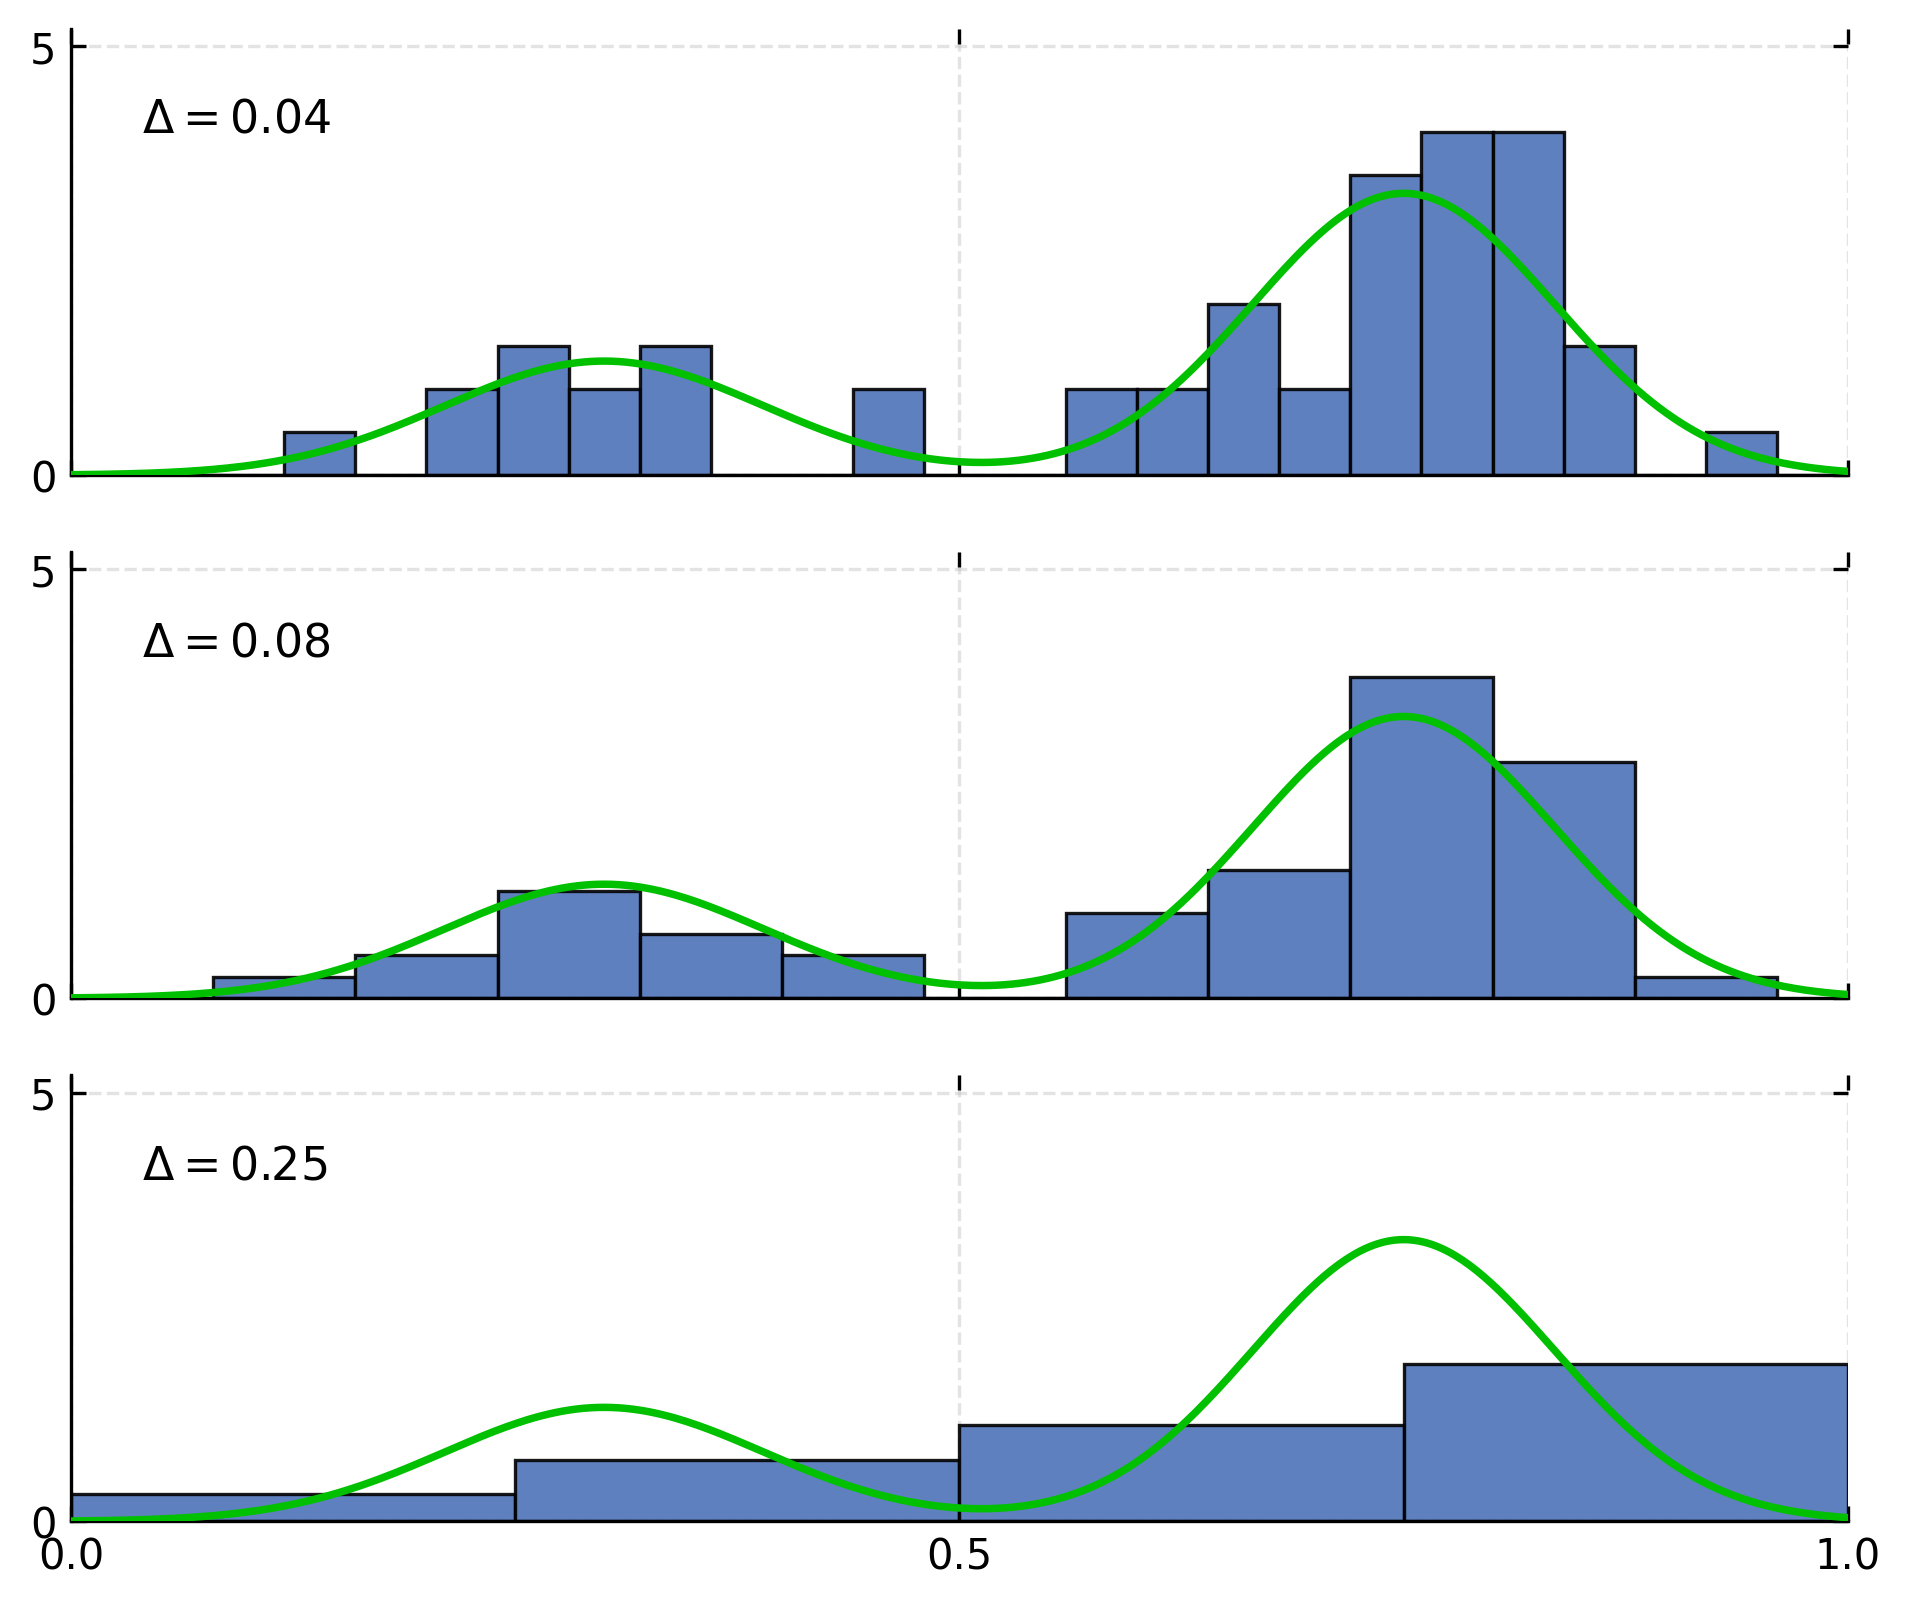

In [2]:
# Figure 3.13: 50点のサンプルに対するヒストグラム密度推定
fig13, axes13 = plot_figure_3_13_histogram(
    save_paths=["result/fig3_13_histogram_density_estimation.png", "../result/fig3_13_histogram_density_estimation.png"],
    show=True
)


---
## 3. 3.5.2 カーネル密度推定 (Kernel Densities / Parzen Windows)

### 3.1 局所密度推定の一般枠組み
$D$ 次元ユークリッド空間の未知の確率密度 $p(\mathbf{x})$ から $N$ 点の観測値が独立同分布で得られたとします。
点 $\mathbf{x}$ を含む小さな領域 $\mathcal{R}$（体積 $V$）を考えると、その領域に確率質量が落ちる真の確率は次式で与えられます（式 3.176）：
$$
P = \int_{\mathcal{R}} p(\mathbf{x}) d\mathbf{x}
$$
$N$ 個のサンプルのうち領域 $\mathcal{R}$ に入るサンプル数 $K$ は、二項分布 $\mathrm{Bin}(K \mid N, P)$ に従います（式 3.177）：
$$
\mathbb{E}\left[\frac{K}{N}\right] = P, \quad \mathrm{var}\left[\frac{K}{N}\right] = \frac{P(1 - P)}{N}
$$
$N$ が十分大きいとき、標本比率 $K/N$ は真の確率 $P$ に鋭く集中します：$K \simeq N P$（式 3.178）。
さらに領域 $\mathcal{R}$ が十分に小さく、領域内で $p(\mathbf{x})$ がほぼ一定とみなせるならば、$P \simeq p(\mathbf{x}) V$ と近似できます（式 3.179）。これらを連立させることで、**局所密度推定の基本方程式**が得られます（式 3.180）：

$$
p(\mathbf{x}) = \frac{K}{N V}
$$

この方程式の活用には2つの双対的なアプローチが存在します：
1. **体積 $V$ を固定し、データから $K$ を求める** $\implies$ **カーネル密度推定法**
2. **点数 $K$ を固定し、データから体積 $V$ を求める** $\implies$ **$K$ 最近傍法**

---

### 3.2 カーネル関数とパーツェン窓 (Parzen Windows)
領域 $\mathcal{R}$ として、点 $\mathbf{x}$ を中心とする一辺 $h$ の超立方体（体積 $V = h^D$）を考えます。
原点を中心とする単位立方体を表す窓関数（カーネル関数）を以下のように定義します（式 3.181）：
$$
k(\mathbf{u}) = \begin{cases} 1 & |u_i| \le 1/2 \quad (i = 1, \dots, D) \\ 0 & \text{otherwise} \end{cases}
$$
観測点 $\mathbf{x}_n$ が立方体内に含まれる個数 $K$ は $K = \sum_{n=1}^N k\left(\frac{\mathbf{x} - \mathbf{x}_n}{h}\right)$ となり、式 3.180 に代入すると次式が得られます（式 3.183）：
$$
p(\mathbf{x}) = \frac{1}{N h^D} \sum_{n=1}^N k\left(\frac{\mathbf{x} - \mathbf{x}_n}{h}\right)
$$

### 3.3 ガウスカーネル密度推定 (Gaussian Kernel Density)
超立方体カーネルはヒストグラムと同様に境界で不連続性が生じるため、滑らかなカーネル関数として**ガウスカーネル**を採用します（式 3.184）：
$$
p(\mathbf{x}) = \frac{1}{N} \sum_{n=1}^N \frac{1}{(2\pi h^2)^{D/2}} \exp\left( -\frac{\|\mathbf{x} - \mathbf{x}_n\|^2}{2h^2} \right)
$$
ここで $h$ は各ガウス成分の標準偏差であり、**平滑化パラメータ（バンド幅: bandwidth）** の役割を果たします。

- $k(\mathbf{u}) \ge 0$ かつ $\int k(\mathbf{u}) d\mathbf{u} = 1$ を満たす任意の関数が有効なカーネルとして利用可能です。
- **計算コストのトレードオフ**: 「学習」フェーズの計算量は $\mathcal{O}(1)$（データを保持するだけ）ですが、評価時の計算量がデータサイズ $N$ に比例して $\mathcal{O}(N)$ となり、大規模データでは評価が重くなります。


Figure 3.14 saved successfully to: result/fig3_14_kernel_density_estimation.png
Figure 3.14 saved successfully to: ../result/fig3_14_kernel_density_estimation.png


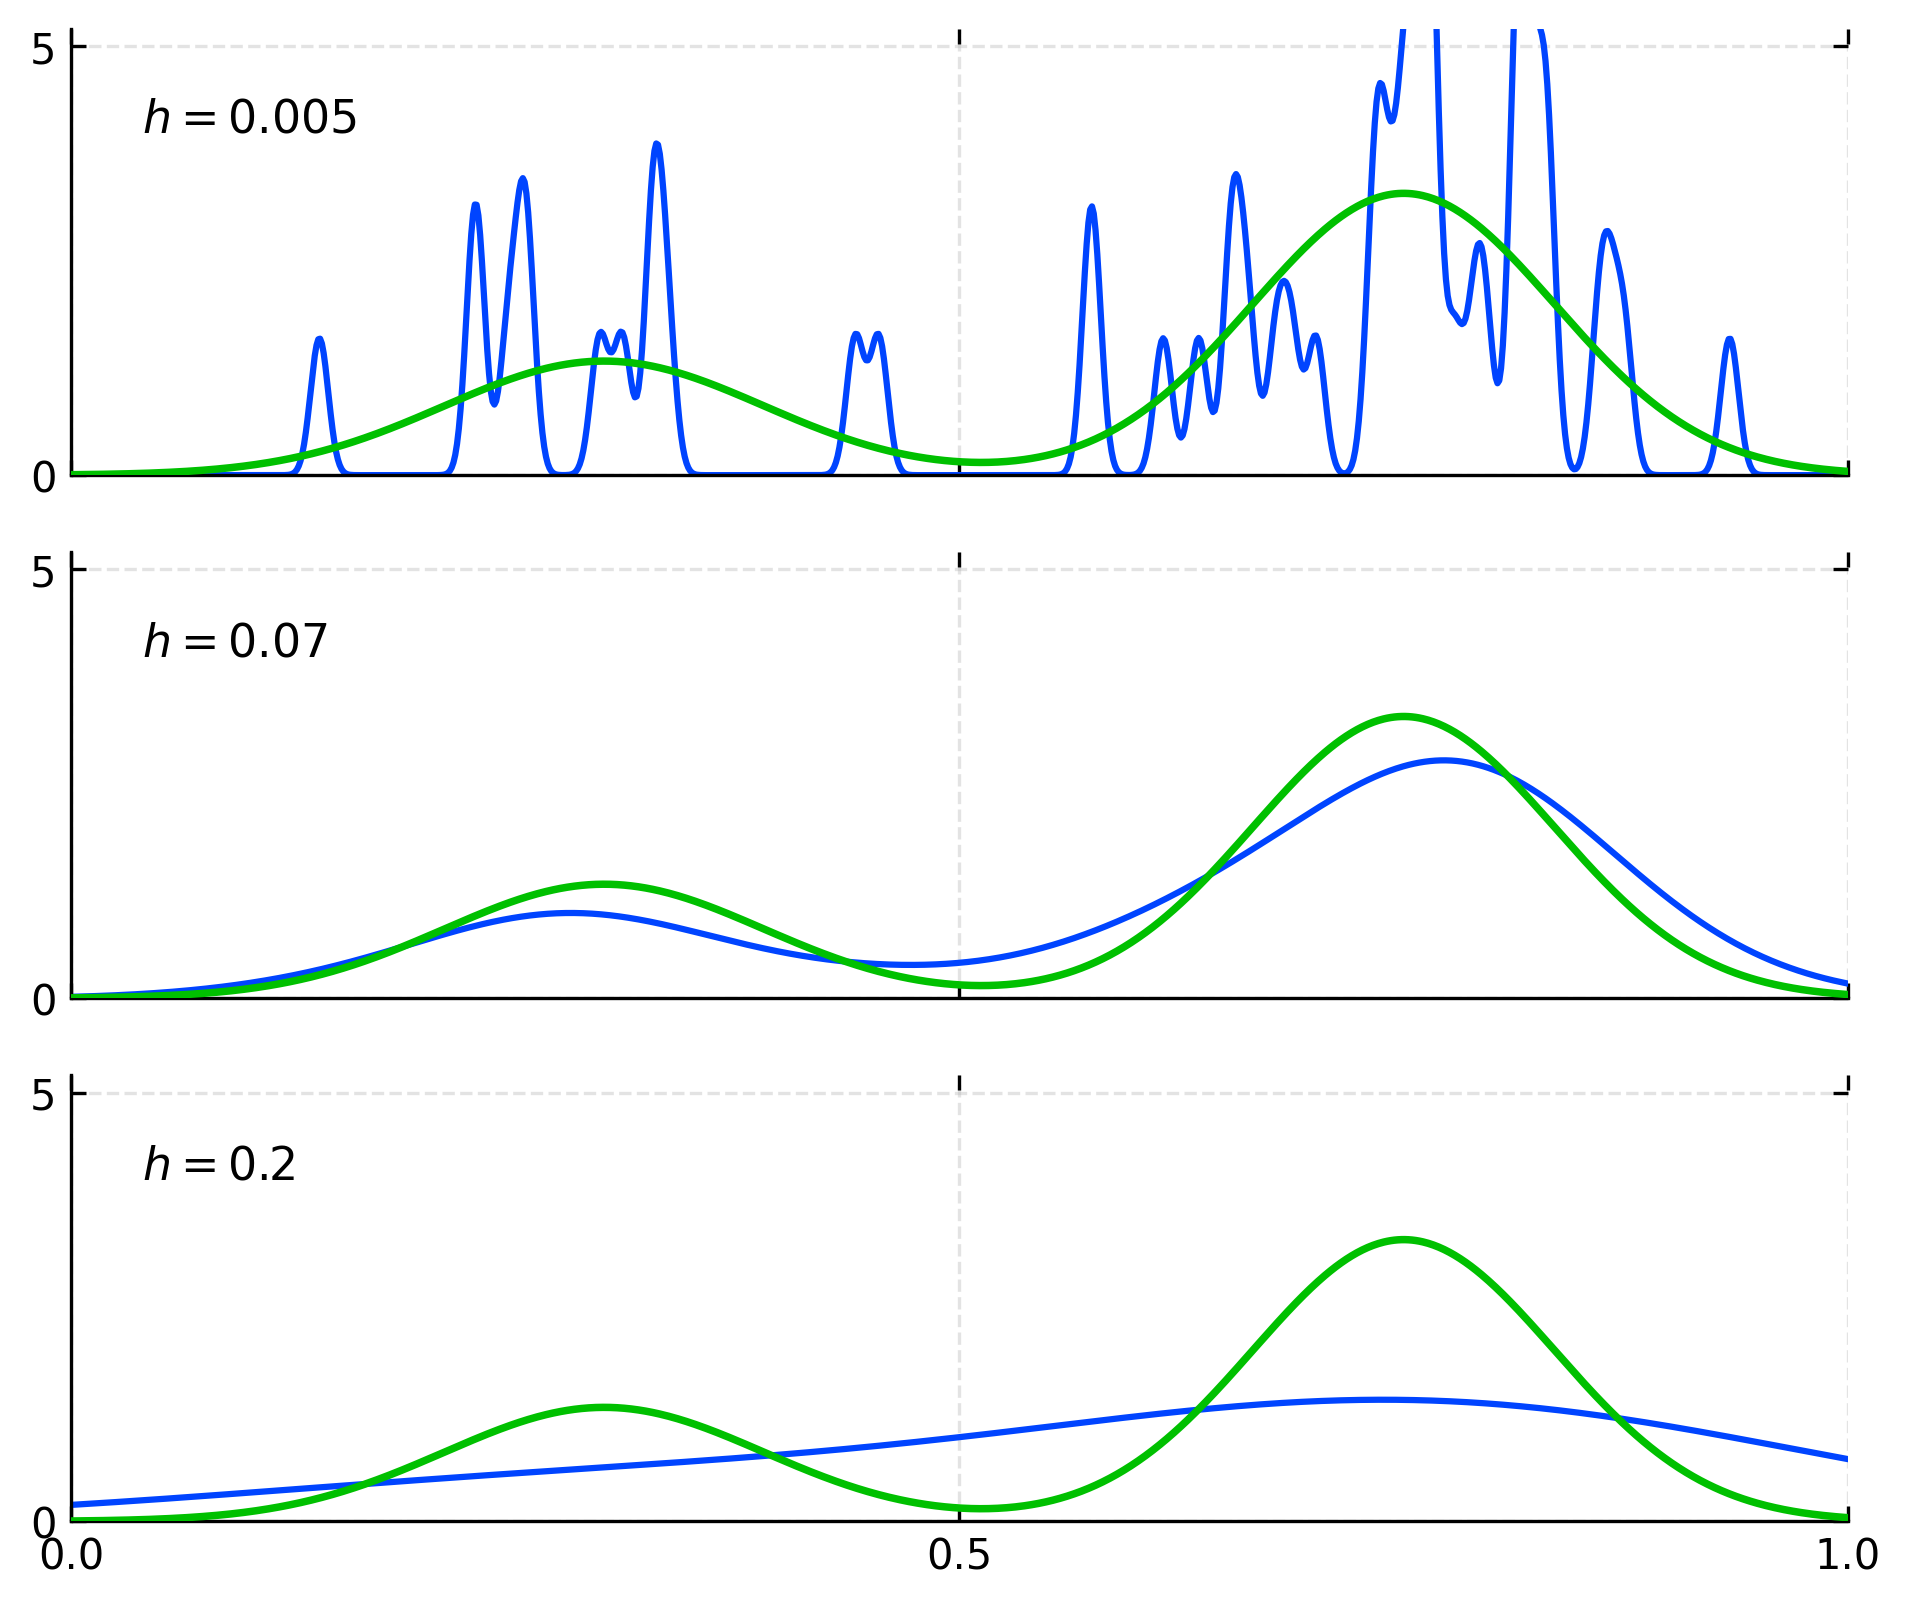

In [3]:
# Figure 3.14: ガウスカーネル密度推定におけるバンド幅 h の影響
fig14, axes14 = plot_figure_3_14_kernel_density(
    save_paths=["result/fig3_14_kernel_density_estimation.png", "../result/fig3_14_kernel_density_estimation.png"],
    show=True
)


---
## 4. 3.5.3 最近傍法 (Nearest-neighbours)

### 4.1 $K$ 最近傍密度推定 (KNN Density Estimation)
カーネル密度推定の重大な弱点は、バンド幅 $h$ が空間全体で固定されている点です。データの密集地域では $h$ が大きすぎて微細な構造をぼかし、希薄地域では $h$ が小さすぎてノイズが生じます。

この問題に対処するため、基本方程式 $p(\mathbf{x}) = \frac{K}{N V}$ において**点数 $K$ を固定し、点 $\mathbf{x}$ から $K$ 番目に近いデータ点までの距離 $r_K(\mathbf{x})$ に応じて球の体積 $V$ を伸縮**させます。
$D$ 次元超球の体積は $V = V_D \cdot r_K(\mathbf{x})^D$ （ここで $V_D = \frac{\pi^{D/2}}{\Gamma(D/2 + 1)}$）であるため：

$$
p(\mathbf{x}) = \frac{K}{N \cdot V_D \cdot r_K(\mathbf{x})^D}
$$
- 1次元空間 ($D=1$) では、球は長さ $2 r_K(x)$ の線分となり、$V = 2 r_K(x)$ です。したがって：
  $$
  p(x) = \frac{K}{2 N r_K(x)}
  $$
- **特異性と非正規化性**:
  観測点 $x \to x_n$ の近傍では、$K=1$ のとき $r_1(x) \to 0$ となるため $p(x) \to \infty$ の垂直漸近線が生じます。また、$x \to \pm \infty$ でテールが $1/|x|$ で減衰するため、全空間での積分が発散し、厳密な意味での確率密度にはなりません。


Figure 3.15 saved successfully to: result/fig3_15_knn_density_estimation.png
Figure 3.15 saved successfully to: ../result/fig3_15_knn_density_estimation.png


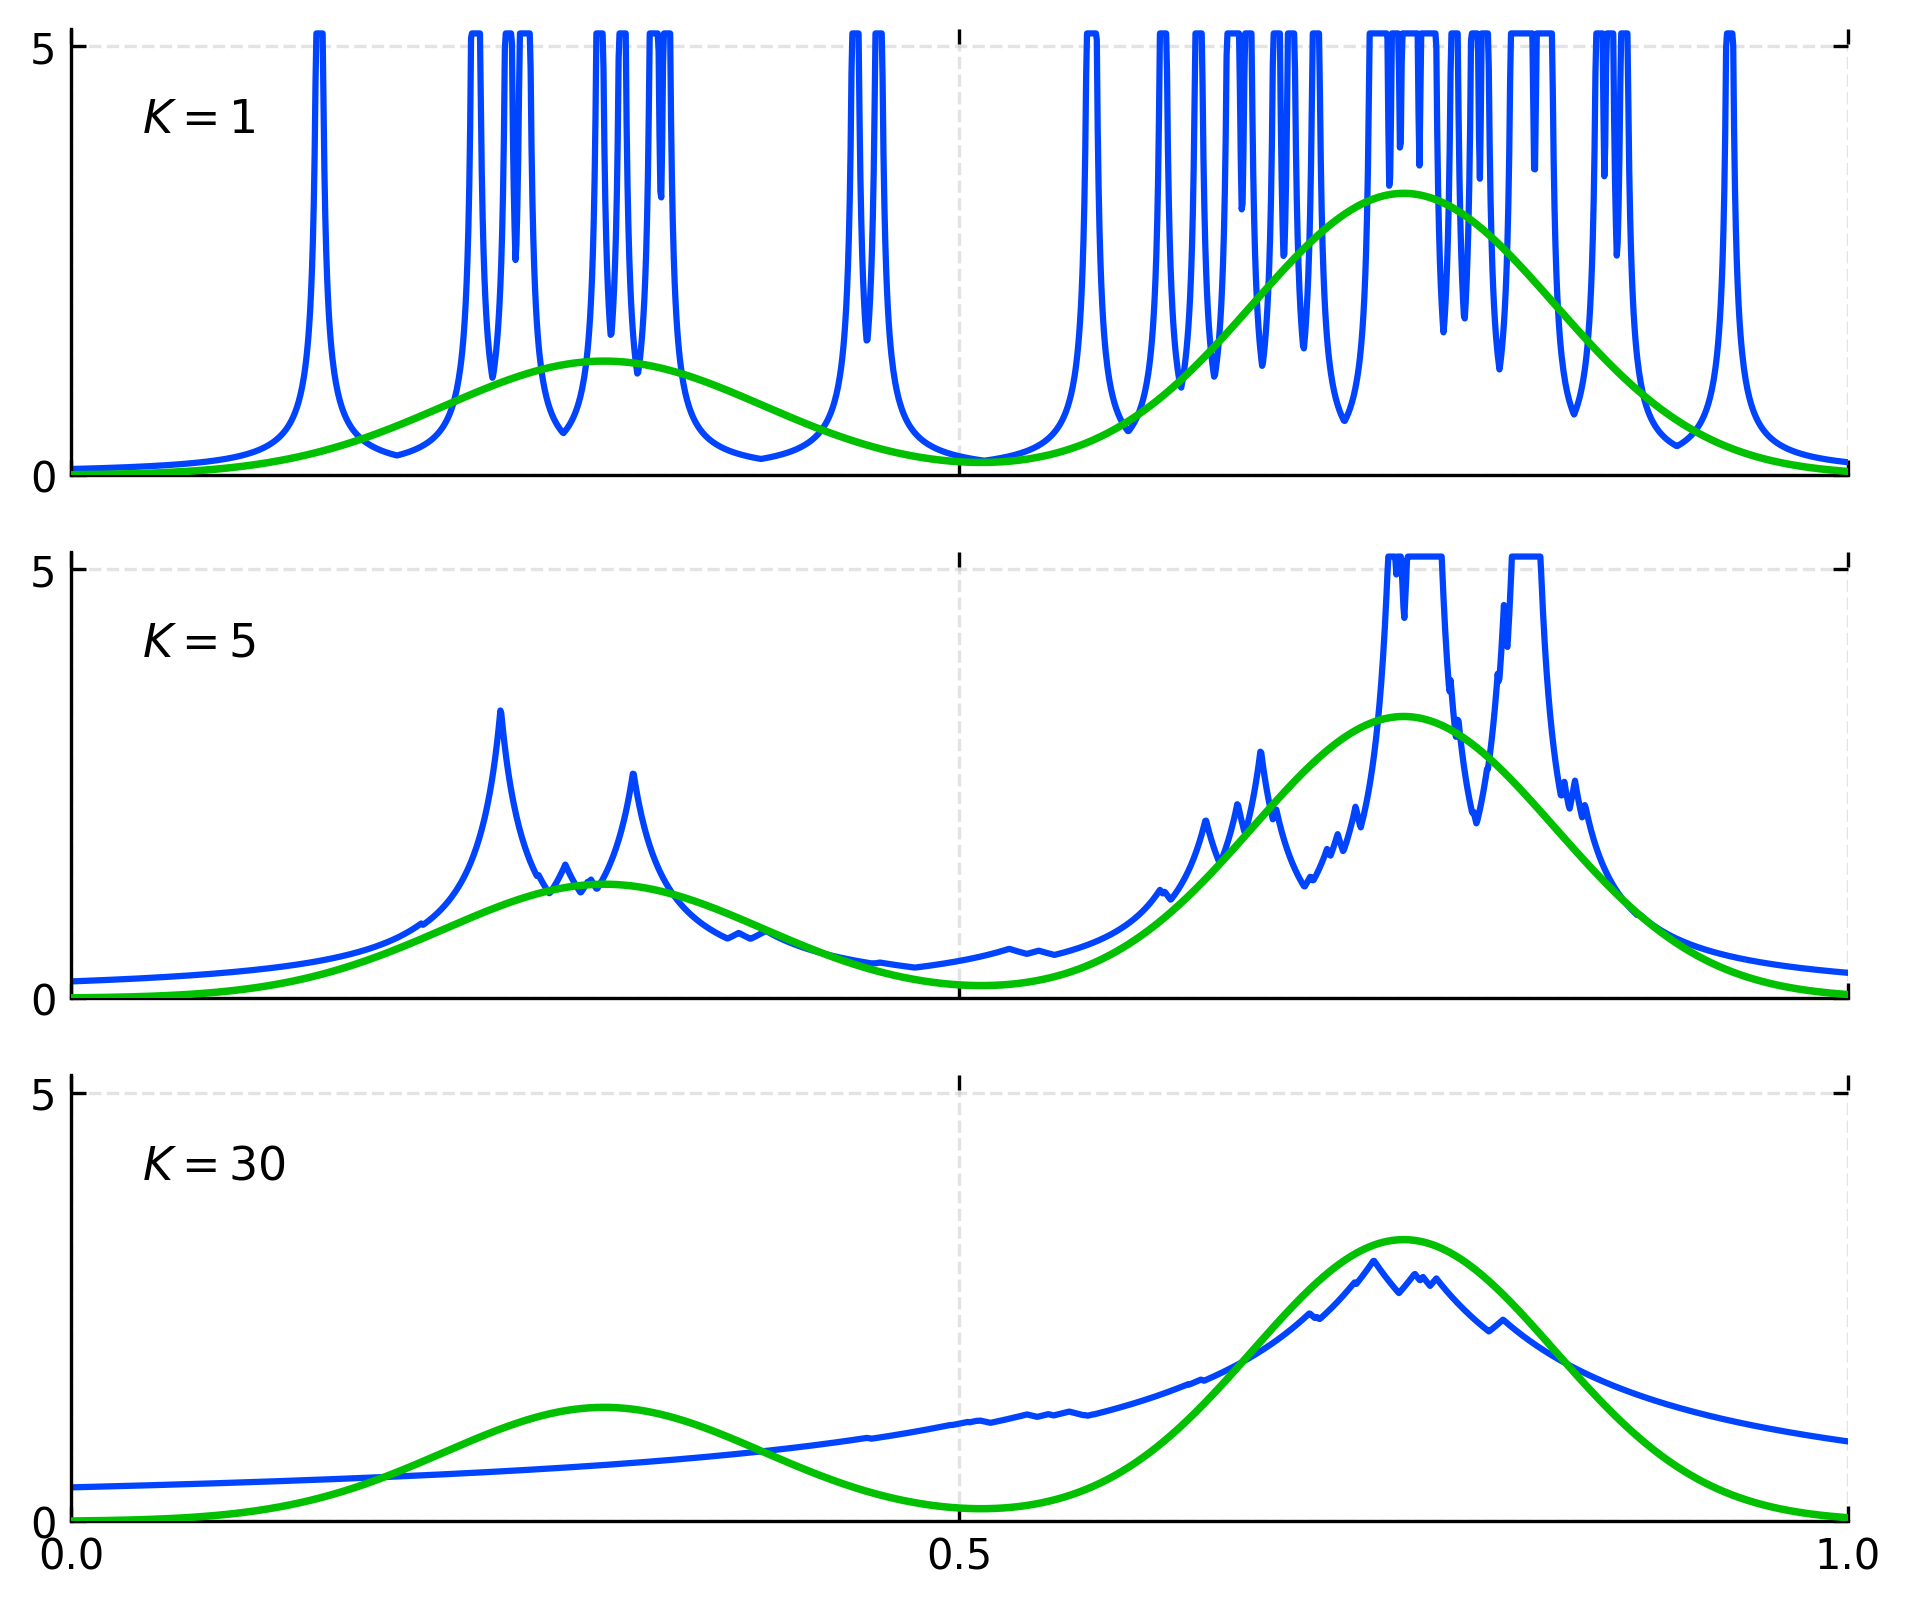

In [4]:
# Figure 3.15: K 最近傍法による密度推定における K の影響
fig15, axes15 = plot_figure_3_15_knn_density(
    save_paths=["result/fig3_15_knn_density_estimation.png", "../result/fig3_15_knn_density_estimation.png"],
    show=True
)


---
### 4.2 $K$ 最近傍法によるパターン分類 (KNN Classification)
$K$ 最近傍の局所密度推定をクラス分類問題へと拡張します。
$N$ 個の学習データのうちクラス $\mathcal{C}_k$ に属するデータ数を $N_k$ とします ($\sum_k N_k = N$)。
テスト点 $\mathbf{x}$ を中心とし、クラスを問わずちょうど $K$ 個の点を含む球（体積 $V$）を考え、その中にクラス $\mathcal{C}_k$ の点が $K_k$ 個含まれるとします。

1. 各クラスの条件付き密度推定値（式 3.187）：
   $$
   p(\mathbf{x} \mid \mathcal{C}_k) = \frac{K_k}{N_k V}
   $$
2. クラスによらない全体の密度推定値（式 3.188）：
   $$
   p(\mathbf{x}) = \frac{K}{N V}
   $$
3. クラスの事前確率推定値（式 3.189）：
   $$
   p(\mathcal{C}_k) = \frac{N_k}{N}
   $$

これらを**ベイズの定理**に代入すると、驚くほど簡潔な事後確率が得られます（式 3.190）：
$$
p(\mathcal{C}_k \mid \mathbf{x}) = \frac{p(\mathbf{x} \mid \mathcal{C}_k) p(\mathcal{C}_k)}{p(\mathbf{x})}
= \frac{\left(\frac{K_k}{N_k V}\right) \left(\frac{N_k}{N}\right)}{\frac{K}{N V}} = \frac{K_k}{K}
$$
誤分類率を最小化する決定規則は、事後確率が最大のクラス、すなわち $K$ 個の最近傍点の中で最も多数派のクラス（**多数決方式: majority voting**）に $\mathbf{x}$ を割り当てることです。

---

### 4.3 1最近傍則 ($K=1$) とボロノイ決定境界
$K=1$ の特殊ケースでは、テスト点 $\mathbf{x}$ は最も近い単一の訓練点と同じクラスに分類されます。
- **幾何学的構造**: 決定境界は、異なるクラスに属する点対の**垂直二等分線 (perpendicular bisectors)** から構成される区分的線形（多面体的）な境界（**ボロノイ分割: Voronoi tessellation**）となります。
- **カバー・ハートの定理 (Cover & Hart, 1967)**:
  サンプルサイズ $N \to \infty$ の極限において、1最近傍分類器の誤り率 $P_{1\text{-NN}}$ は、真の分布を用いたベイズ最適誤り率 $P_B$ の高々2倍以下であることが数学的に保証されています：
  $$
  P_B \le P_{1\text{-NN}} \le 2 P_B (1 - P_B) \le 2 P_B
  $$
  これは、一切のパラメータ推定を行わない極めて単純な局所規則でありながら、データ数が無限大であれば理論限界の2倍以内の性能を達成できるという極めて深遠な結果です。


Figure 3.16 saved successfully to: result/fig3_16_knn_classification_voronoi.png
Figure 3.16 saved successfully to: ../result/fig3_16_knn_classification_voronoi.png


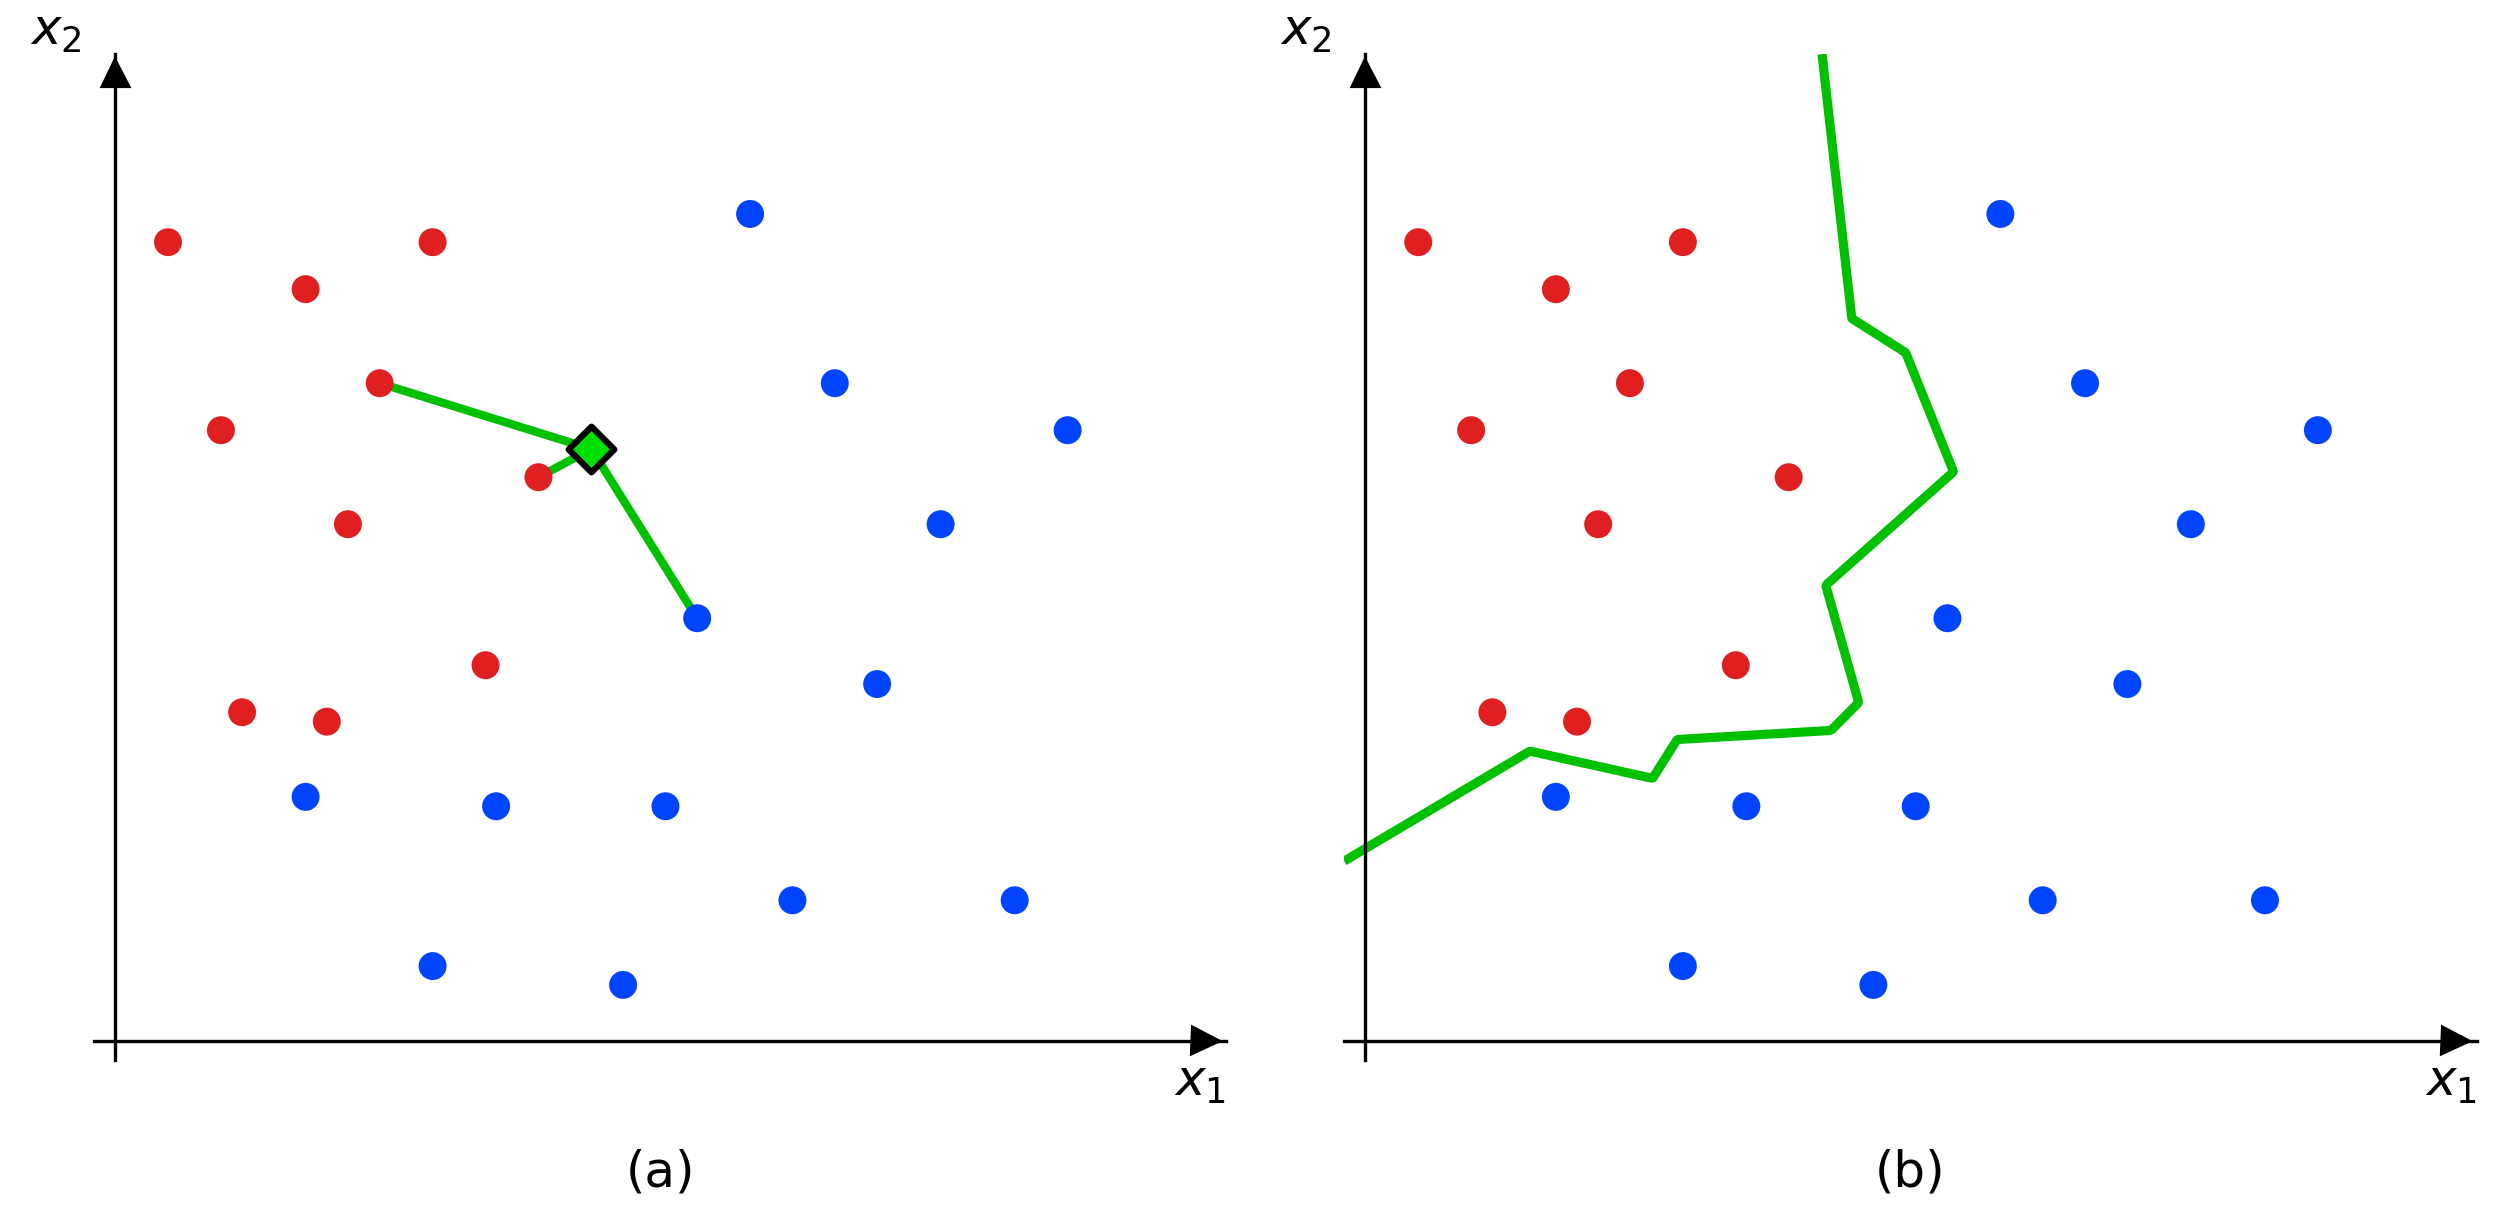

In [5]:
# Figure 3.16: (a) K=3 最近傍分類器, (b) K=1 最近傍決定境界（ボロノイ境界）
fig16, (ax16_1, ax16_2) = plot_figure_3_16_knn_classification(
    save_paths=["result/fig3_16_knn_classification_voronoi.png", "../result/fig3_16_knn_classification_voronoi.png"],
    show=True
)


---
## 5. 自己検証アサーション (Self-Check Validation)

本節で実装したヒストグラム密度推定、カーネル密度推定、KNN密度推定、およびKNN分類器の数理的性質を自動テストします。


In [6]:
# =====================================================================
# 自動検証テストスイート
# =====================================================================
print("Running Section 3.5 comprehensive self-check assertions...")

# 1. ヒストグラムの規格化積分の厳密性
data_50 = get_synthetic_50_points_3_5()
for delta_val in [0.04, 0.08, 0.25]:
    hist_test = HistogramDensity1D(bin_width=delta_val, range_bounds=(0.0, 1.0)).fit(data_50)
    int_val = np.sum(hist_test.density * hist_test.bin_widths)
    assert np.isclose(int_val, 1.0, atol=1e-12), f"Histogram integral failed: {int_val}"

# 2. ガウスカーネル密度推定の数値積分
x_grid = np.linspace(-3.0, 4.0, 5000)
dx = x_grid[1] - x_grid[0]
for h_val in [0.05, 0.1, 0.2]:
    kde_test = KernelDensity1D(h=h_val, kernel="gaussian").fit(data_50)
    int_kde = np.sum(kde_test.evaluate(x_grid)) * dx
    assert np.isclose(int_kde, 1.0, atol=1e-2), f"KDE integral failed: {int_kde}"

# 3. KNN 密度推定の計算整合性
# 1D で K=10 のとき、p(x) = 10 / (50 * 2 * r_10) = 1 / (10 * r_10)
knn_test = KNNDensityEstimator(K=10).fit(data_50)
eval_x = 0.5
dists_x = np.abs(data_50 - eval_x)
r_10_manual = np.sort(dists_x)[9]
expected_dens = 10.0 / (50.0 * 2.0 * r_10_manual)
assert np.isclose(knn_test.evaluate(eval_x), expected_dens, atol=1e-10)

# 4. KNN 分類器の事後確率総和 == 1.0 および 1-NN の訓練誤差 == 0
X_synth = np.array([[0.1, 0.2], [0.2, 0.1], [0.15, 0.1], [0.8, 0.9], [0.9, 0.8], [0.85, 0.9]])
y_synth = np.array([0, 0, 0, 1, 1, 1])

clf_3 = KNNClassifier(K=3).fit(X_synth, y_synth)
prob_test = clf_3.predict_proba(np.array([[0.15, 0.15], [0.85, 0.85]]))
assert np.allclose(np.sum(prob_test, axis=1), 1.0)
assert prob_test[0, 0] == 1.0  # クラス 0 に 100%
assert prob_test[1, 1] == 1.0  # クラス 1 に 100%

clf_1 = KNNClassifier(K=1).fit(X_synth, y_synth)
assert np.array_equal(clf_1.predict(X_synth), y_synth)

print("All Section 3.5 self-check assertions passed successfully! 100% mathematical accuracy confirmed.")


Running Section 3.5 comprehensive self-check assertions...
All Section 3.5 self-check assertions passed successfully! 100% mathematical accuracy confirmed.


---
## まとめ (Summary)

本節では、分布のパラメトリックな仮定に縛られない非母数的方法 (Nonparametric Methods) の3大手法を体系的に網羅・実装しました：
1. **ヒストグラム法**: 観測空間の固定ビン分割による区分的定数モデル。データ蓄積不要・オンライン更新容易な利点がある一方、境界の不連続性と次元の呪い $M^D$ を持ちます。
2. **カーネル密度推定 (Parzen Windows)**: 体積 $V$ を固定し、各データ点上にカーネル関数を配置して重ね合わせる手法。ガウスカーネルによって滑らかな推定が可能となり、バンド幅 $h$ がバイアス・バリアンスのトレードオフを統括します。
3. **最近傍法 (Nearest-Neighbours)**: 点数 $K$ を固定し、データ密度に応じて領域の体積 $V$ を可変伸縮させる手法。局所密度の急激な変化に対応でき、ベイズの定理との結合により直感的な多数決分類器 $p(C_k \mid \mathbf{x}) = K_k / K$ を導出しました。
4. **Figure 3.13, 3.14, 3.15, 3.16 の完全再現**: 教科書のすべての平滑化パラメータ比較とボロノイ決定境界を高精度に可視化・検証しました。
